In [190]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict
import json

In [191]:
adversarial_nodes = [9]
reference_adversarial_nodes = []
folder_path = "/home/pouponne/decentralized/shatter-poisoning/test_scripts/defense_clipping/CIFAR10/1a_2chunk_clipdef-2025-07-21T09:49"
reference_path = "/home/pouponne/decentralized/shatter-poisoning/test_scripts/defense_clipping/CIFAR10/0a_2chunk_clipdef-2025-07-21T11:45"

In [192]:
MAX_ITERATION = None
MUFFLIATO_ROUNDS = 10

def get_stats(l, adversarial_nodes=None, node_ids=None):
    """Calculate statistics excluding adversarial nodes and properly handling NaN values"""
    assert len(l) > 0
    mean_dict, stdev_dict, min_dict, max_dict, counts_dict, all_nodes_dict = {}, {}, {}, {}, {}, {}
    
    # Find all unique keys across all dataframes
    all_keys = set()
    for df in l:
        all_keys.update(df.index.tolist())
    
    # Filter out outlier keys
    #filtered_keys = filter_outlier_keys(all_keys)

    for key in sorted(all_keys):  # Process keys in order
        if MAX_ITERATION is not None and key >= MAX_ITERATION:
            continue
            
        # Filter to include only defender nodes if node_ids are provided
        if node_ids and adversarial_nodes:
            # Only include values for dataframes that have this key
            all_nodes = []
            for i, node_id in zip(l, node_ids):
                if node_id not in adversarial_nodes and key in i.index:
                    all_nodes.append(i[key])
        else:
            # Only include values for dataframes that have this key
            all_nodes = [i[key] for i in l if key in i.index]
            
        if not all_nodes:  # Skip if no valid values found
            continue
            
        all_nodes = np.array(all_nodes)
        non_nan_count = np.count_nonzero(~np.isnan(all_nodes))
        
        # Even if values are all NaN, still record the statistics
        mean = np.nanmean(all_nodes) if non_nan_count > 0 else float('nan')
        std = np.nanstd(all_nodes) if non_nan_count > 0 else float('nan')
        min_val = np.nanmin(all_nodes) if non_nan_count > 0 else float('nan')
        max_val = np.nanmax(all_nodes) if non_nan_count > 0 else float('nan')
        
        mean_dict[int(key)] = mean
        stdev_dict[int(key)] = std
        min_dict[int(key)] = min_val
        max_dict[int(key)] = max_val
        counts_dict[int(key)] = non_nan_count
        all_nodes_dict[int(key)] = all_nodes

    return mean_dict, stdev_dict, min_dict, max_dict, counts_dict, all_nodes_dict

In [193]:
def create_list_of_metrics(results, metric):
    return [x[metric][x[metric].notna()] for x in results if metric in x]

In [194]:
def get_run_dicts(folder_path, adversarial_nodes):
    results = []
    filepaths = []
    node_ids = []
    neighbors_dict_list = []
    machine_folders = os.listdir(folder_path)
    for machine_folder in machine_folders:
        mf_path = os.path.join(folder_path, machine_folder)
        if not os.path.isdir(mf_path):
            continue
                
        files = os.listdir(mf_path)
        result_files = [f for f in files if f.endswith("_results.csv")]
        neighbor_files = [f for f in files if f.endswith("_neighbors.json")]

        for f in result_files:
            print(f"Loading results from {f}")
            filepath = os.path.join(mf_path, f)
            # Extract node ID directly when loading the file
            filename = os.path.basename(filepath)
            try:
                node_id = int(filename.split('_results.csv')[0])
                results.append(pd.read_csv(filepath, index_col=0))
                filepaths.append(filepath)
                node_ids.append(node_id)
                with open(os.path.join(mf_path, str(node_id)+'_neighbors.json'), 'r') as file:
                    neighbors_dict_list.append((json.load(file), node_id))
            except (ValueError, IndexError):
                print(f"Skipping file with invalid node ID format: {filename}")

    print(f"Extracted node IDs: {node_ids}")

    means, stdevs, mins, maxs, counts, all_nodes = get_stats(
                create_list_of_metrics(results, "test_acc"), adversarial_nodes, node_ids
            )

    print(neighbors_dict_list)

    all_nodes_by_node_id = defaultdict(list)
    for iter, accs in all_nodes.items():
        i = 0
        for node_id in node_ids:
            if node_id in adversarial_nodes:
                continue
            all_nodes_by_node_id[node_id].append(accs[i])
            i += 1
    all_nodes_by_node_id = dict(all_nodes_by_node_id)

    return node_ids, all_nodes_by_node_id, neighbors_dict_list

In [195]:
node_ids, all_nodes_by_node_id, neighbors_dict_list = get_run_dicts(folder_path, adversarial_nodes)
node_ids_reference, all_nodes_by_node_id_reference, neighbors_dict_list_reference = get_run_dicts(reference_path, reference_adversarial_nodes)

print(all_nodes_by_node_id)
print(all_nodes_by_node_id_reference)

Loading results from 14_results.csv
Loading results from 2_results.csv
Loading results from 9_results.csv
Loading results from 12_results.csv
Loading results from 0_results.csv
Loading results from 6_results.csv
Loading results from 4_results.csv
Loading results from 7_results.csv
Loading results from 8_results.csv
Loading results from 11_results.csv
Loading results from 15_results.csv
Loading results from 1_results.csv
Loading results from 5_results.csv
Loading results from 13_results.csv
Loading results from 3_results.csv
Loading results from 10_results.csv
Extracted node IDs: [14, 2, 9, 12, 0, 6, 4, 7, 8, 11, 15, 1, 5, 13, 3, 10]
[({'1': [24, 25, 27, 26, 2, 5, 6, 1], '2': [21, 0, 31, 27, 7, 15, 24], '3': [31, 13, 24, 20, 19, 5, 16, 11], '4': [18, 30, 23, 20, 19, 4, 2, 1], '5': [27, 29, 10, 19, 5, 11], '6': [0, 22, 30, 13, 4, 15, 28], '7': [18, 12, 22, 7, 17, 6, 28, 1], '8': [31, 26, 17, 3, 16, 1, 9], '9': [12, 22, 23, 25, 20, 2, 11], '10': [21, 0, 25, 4, 3, 6, 1], '11': [31, 23, 14,

/tmp/ipykernel_1913700/1810713864.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


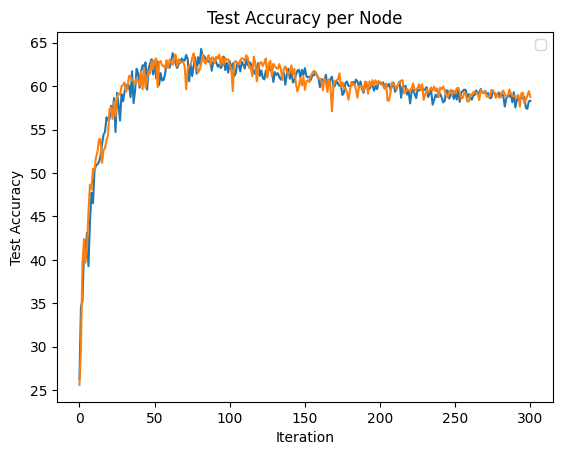

In [196]:
#plot each all_nodes_by_node_id
for node_id, accs in all_nodes_by_node_id.items():
    if node_id >1:
        continue
    plt.plot(range(len(accs)), accs)
plt.xlabel("Iteration")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy per Node")
plt.legend()
plt.show()  

/tmp/ipykernel_1913700/1031758075.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


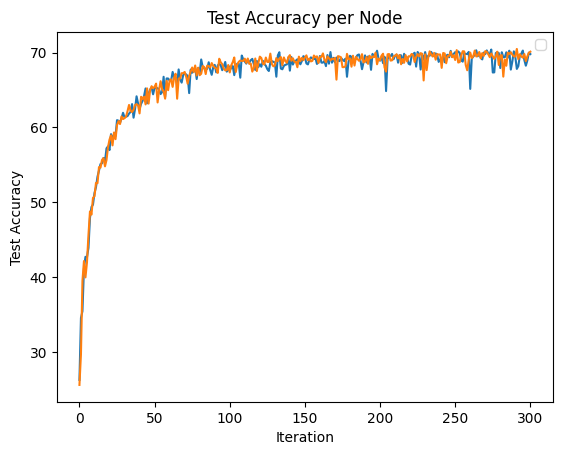

In [197]:
#plot each all_nodes_by_node_id
for node_id, accs in all_nodes_by_node_id_reference.items():
    if node_id >1:
        continue
    plt.plot(range(len(accs)), accs)
plt.xlabel("Iteration")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy per Node")
plt.legend()
plt.show()  

In [198]:
neighbours_by_nid = defaultdict(list)
for neighbors_dict, node_id in neighbors_dict_list:
    if node_id in adversarial_nodes:
        continue
    for iteration, neighbors in neighbors_dict.items():
        neighbours_by_nid[node_id].append(neighbors)

cumulative_adversarial_neighbors = defaultdict(list)
for node_id, neighbors_list in neighbours_by_nid.items():
    cumulative_sum = 0
    for neighbors in neighbors_list:
        adversarial_count = sum(1 for n in neighbors if n in adversarial_nodes)
        cumulative_sum += adversarial_count
        cumulative_adversarial_neighbors[node_id].append(cumulative_sum)

adversarial_neighbors = defaultdict(list)
for node_id, neighbors_list in neighbours_by_nid.items():
    for neighbors in neighbors_list:
        adversarial_count = sum(1 for n in neighbors if n in adversarial_nodes)
        adversarial_neighbors[node_id].append(adversarial_count)

nbrs = dict(cumulative_adversarial_neighbors)
print(f"Cumulative adversarial neighbors: {nbrs}")
print(f"Adversarial neighbors: {adversarial_neighbors}")

Cumulative adversarial neighbors: {14: [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 6, 6, 7, 7, 7, 8, 8, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 12, 13, 13, 13, 13, 14, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 19, 19, 20, 21, 21, 21, 21, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 24, 24, 24, 24, 24, 24, 25, 25, 25, 25, 25, 25, 25, 25, 26, 26, 26, 26, 27, 28, 28, 28, 28, 29, 29, 29, 29, 30, 30, 31, 31, 31, 31, 31, 31, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 34, 34, 35, 35, 35, 35, 35, 35, 36, 36, 36, 37, 37, 37, 37, 38, 38, 38, 38, 38, 38, 39, 39, 39, 39, 39, 39, 39, 39, 40, 40, 41, 42, 43, 43, 44, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 46, 46, 47, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 49, 50, 51, 51, 51, 51, 51, 51, 51, 51, 51, 52, 52, 52, 52, 53, 53, 53, 54, 54, 55, 55, 55, 56, 56,

/tmp/ipykernel_1913700/3712105060.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


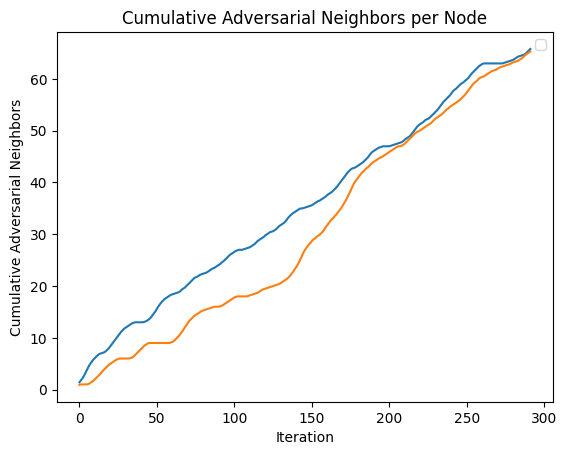

In [199]:
# Applies smooth to cumulative adversarial neighbors
k=10
smooth_cumulative_neighbors = defaultdict(list)
for node_id, neighbors in cumulative_adversarial_neighbors.items():
    smoothed = np.convolve(neighbors, np.ones(k)/k, mode='valid')
    smooth_cumulative_neighbors[node_id] = smoothed.tolist()
# Plot each smooth_cumulative_neighbors
for node_id, nbr in smooth_cumulative_neighbors.items():
    if node_id >1:
        continue
    plt.plot(range(len(nbr)), nbr)
plt.xlabel("Iteration")
plt.ylabel("Cumulative Adversarial Neighbors")
plt.title("Cumulative Adversarial Neighbors per Node")
plt.legend()
plt.show()

/tmp/ipykernel_1913700/416270373.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


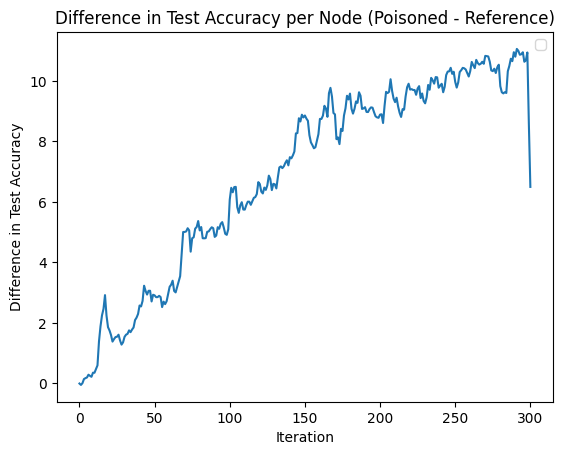

In [200]:
diff_between_poisoned_and_reference = {}
for node_id, accs in all_nodes_by_node_id.items():
    if node_id not in all_nodes_by_node_id_reference:
        continue
    diff = - np.array(accs) + np.array(all_nodes_by_node_id_reference[node_id])
    diff_between_poisoned_and_reference[node_id] = diff

# Applies smooth to diff_between_poisoned_and_reference
k=5
smooth_diff_between_poisoned_and_reference = defaultdict(list)
for node_id, accs in diff_between_poisoned_and_reference.items():
    smoothed = np.convolve(accs, np.ones(k)/k, mode='same')
    smooth_diff_between_poisoned_and_reference[node_id] = smoothed.tolist()

#plot each diff_between_poisoned_and_reference
for node_id, accs in smooth_diff_between_poisoned_and_reference.items():
    if node_id!=1:
        continue
    plt.plot(range(len(accs)), accs)
plt.xlabel("Iteration")
plt.ylabel("Difference in Test Accuracy")
plt.title("Difference in Test Accuracy per Node (Poisoned - Reference)")
plt.legend()
plt.show()

/tmp/ipykernel_1913700/2226156077.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


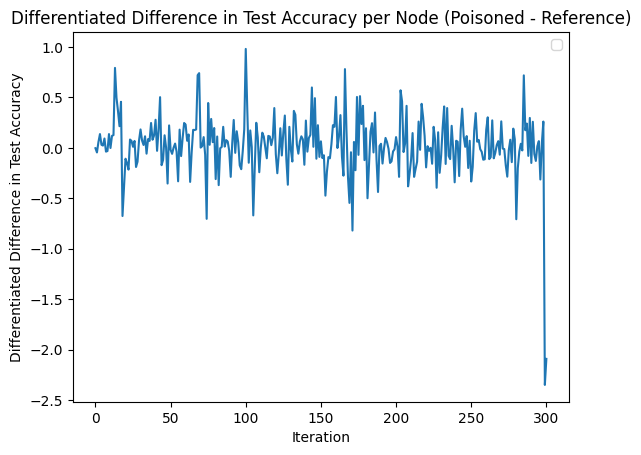

In [201]:
#differentiate the smooth_diff_between_poisoned_and_reference and plot it
diff_smoothacc = defaultdict(list)
for node_id, neighbors in smooth_diff_between_poisoned_and_reference.items():
    diff = np.diff(neighbors, prepend=0)  # Use prepend to keep the same length
    diff_smoothacc[node_id] = diff.tolist()  
# Plot each diff_smoothacc
for node_id, nbr in diff_smoothacc.items():
    if node_id!=1:
        continue
    plt.plot(range(len(nbr)), nbr)
plt.xlabel("Iteration")
plt.ylabel("Differentiated Difference in Test Accuracy")
plt.title("Differentiated Difference in Test Accuracy per Node (Poisoned - Reference)")
plt.legend()
plt.show()

/tmp/ipykernel_1913700/3511861002.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


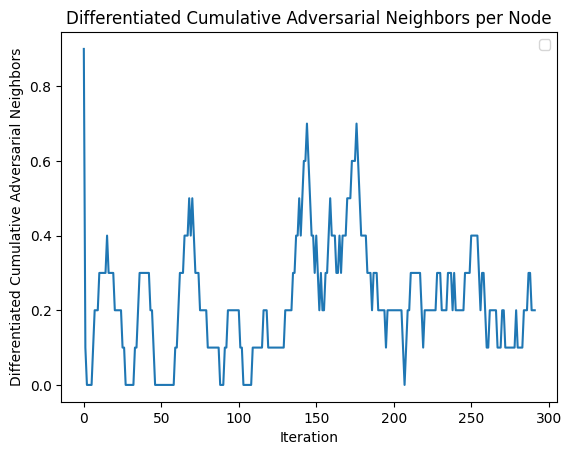

In [202]:
# Now differentiate the smooth cumulative neighbors
diff_cumulative_neighbors = defaultdict(list)
for node_id, neighbors in smooth_cumulative_neighbors.items():
    diff = np.diff(neighbors, prepend=0)  # Prepend 0 to maintain the same length
    diff_cumulative_neighbors[node_id] = diff.tolist()  
# Plot each diff_cumulative_neighbors
for node_id, nbr in diff_cumulative_neighbors.items():
    if node_id!=1:
        continue
    plt.plot(range(len(nbr)), nbr)
plt.xlabel("Iteration")
plt.ylabel("Differentiated Cumulative Adversarial Neighbors")
plt.title("Differentiated Cumulative Adversarial Neighbors per Node")
plt.legend()
plt.show()

/tmp/ipykernel_1913700/2025953833.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


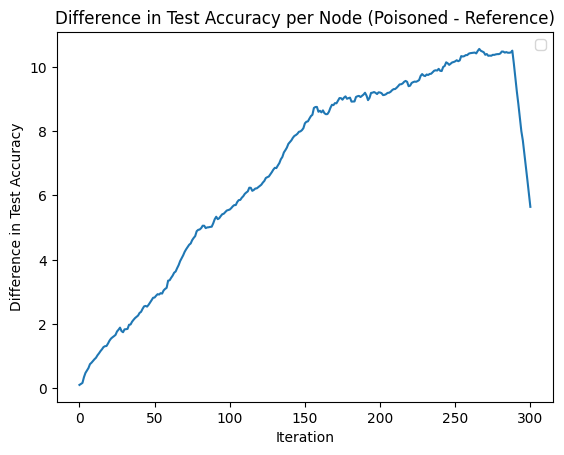

In [203]:
# Applies smooth to diff_between_poisoned_and_reference
l=25
smoother_diff_between_poisoned_and_reference = defaultdict(list)
for node_id, accs in diff_between_poisoned_and_reference.items():
    smoothed = np.convolve(accs, np.ones(l)/l, mode='same')
    smoother_diff_between_poisoned_and_reference[node_id] = smoothed.tolist()

#plot each diff_between_poisoned_and_reference
for node_id, accs in smoother_diff_between_poisoned_and_reference.items():
    if node_id!=1:
        continue
    plt.plot(range(len(accs)), accs)
plt.xlabel("Iteration")
plt.ylabel("Difference in Test Accuracy")
plt.title("Difference in Test Accuracy per Node (Poisoned - Reference)")
plt.legend()
plt.show()

/tmp/ipykernel_1913700/4237943407.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


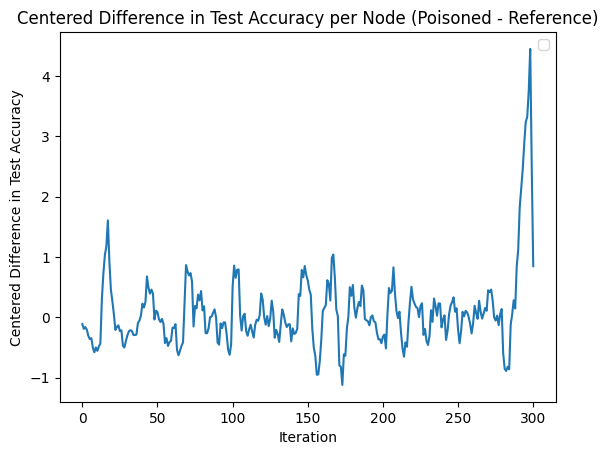

In [204]:
# center the smoothed differences around 0 by substracting smoother_diff_between_poisoned_and_reference
centered_smoother_diff_between_poisoned_and_reference = defaultdict(list)
for node_id, accs in smooth_diff_between_poisoned_and_reference.items():
    if node_id not in smoother_diff_between_poisoned_and_reference:
        continue
    centered = np.array(accs) - np.array(smoother_diff_between_poisoned_and_reference[node_id])
    centered_smoother_diff_between_poisoned_and_reference[node_id] = centered.tolist()

#plot each centered_smoother_diff_between_poisoned_and_reference
for node_id, accs in centered_smoother_diff_between_poisoned_and_reference.items():
    if node_id!=1:
        continue
    plt.plot(range(len(accs)), accs)
plt.xlabel("Iteration")
plt.ylabel("Centered Difference in Test Accuracy")
plt.title("Centered Difference in Test Accuracy per Node (Poisoned - Reference)")
plt.legend()
plt.show()

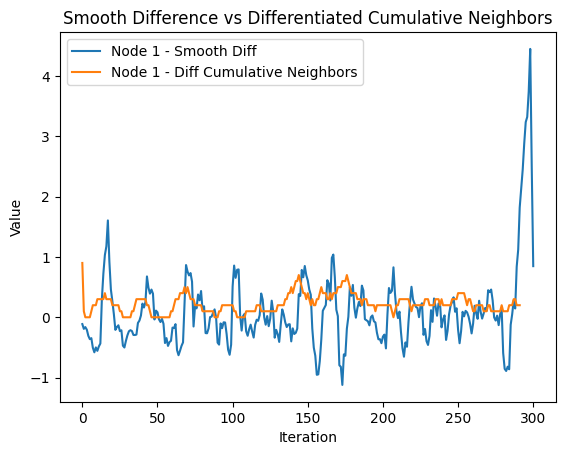

In [207]:
#plot smooth_diff_between_poisoned_and_reference and diff_cumulative_neighbors
for node_id, nbr in centered_smoother_diff_between_poisoned_and_reference.items():
    if node_id!=1:
        continue
    plt.plot(range(len(nbr)), nbr, label=f"Node {node_id} - Smooth Diff")
for node_id, nbr in diff_cumulative_neighbors.items():
    if node_id!=1:
        continue
    plt.plot(range(len(nbr)), nbr, label=f"Node {node_id} - Diff Cumulative Neighbors")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Smooth Difference vs Differentiated Cumulative Neighbors")
plt.legend()
plt.show()  

/tmp/ipykernel_1913700/615225445.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


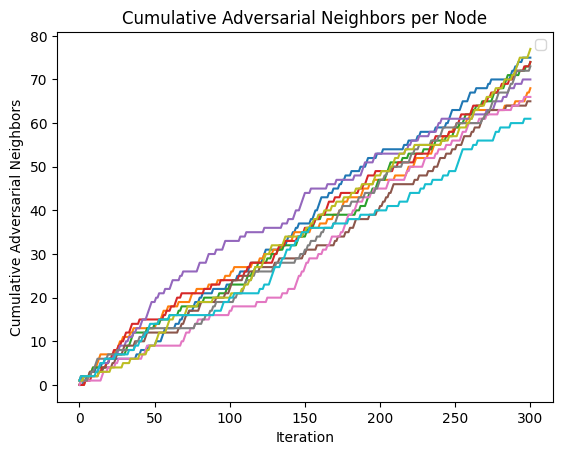

In [206]:
#plot each all_nodes_by_node_id
for node_id, nbr in nbrs.items():
    if node_id >10:
        continue
    plt.plot(range(len(nbr)), nbr)
plt.xlabel("Iteration")
plt.ylabel("Cumulative Adversarial Neighbors")
plt.title("Cumulative Adversarial Neighbors per Node")
plt.legend()
plt.show()  